In [9]:
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data import *
from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

## Correlation analysis

In [10]:
labels_df = get_labels_df()
corr = labels_df.corr()

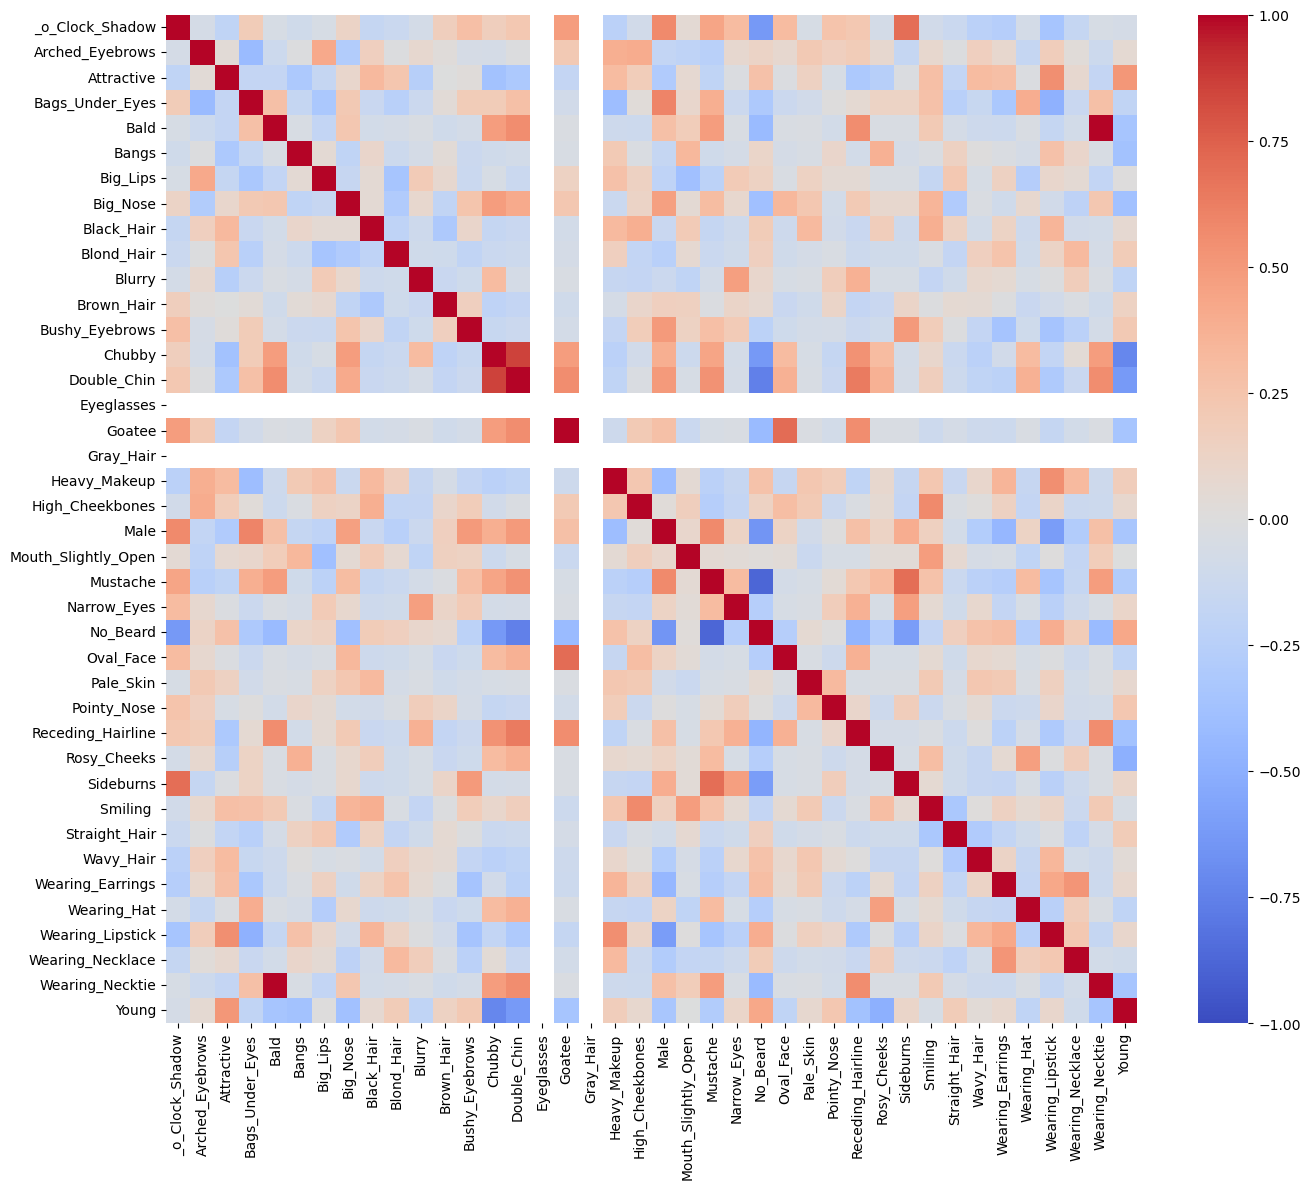

In [11]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

In [12]:
THRESHOLD = 0.3

print(f"\nPairs with |φ| >= {THRESHOLD}:")
pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        phi = corr.iloc[i, j]
        if abs(phi) >= THRESHOLD:
            pairs.append((corr.columns[i], corr.columns[j], phi))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, phi in pairs:
    print(f"  {a:25s} <-> {b:25s}  φ = {phi:+.3f}")


Pairs with |φ| >= 0.3:
  Bald                      <-> Wearing_Necktie            φ = +1.000
  Mustache                  <-> No_Beard                   φ = -0.882
  Chubby                    <-> Double_Chin                φ = +0.854
  Double_Chin               <-> No_Beard                   φ = -0.753
  Chubby                    <-> Young                      φ = -0.724
  Goatee                    <-> Oval_Face                  φ = +0.698
  _o_Clock_Shadow           <-> Sideburns                  φ = +0.688
  Mustache                  <-> Sideburns                  φ = +0.688
  Male                      <-> No_Beard                   φ = -0.655
  Double_Chin               <-> Receding_Hairline          φ = +0.640
  Chubby                    <-> No_Beard                   φ = -0.630
  _o_Clock_Shadow           <-> No_Beard                   φ = -0.630
  Double_Chin               <-> Young                      φ = -0.618
  Male                      <-> Wearing_Lipstick           φ = -0.

In [13]:
def greedy_independent_subset(corr_matrix, threshold=0.2):
    """
    Greedily select attributes such that all pairwise |phi| < threshold.
    Prioritizes attributes with lowest mean absolute correlation to others.
    """
    attrs = list(corr_matrix.columns)
    
    # Rank by mean |phi| with all others (prefer more independent attributes)
    mean_abs_corr = corr_matrix.abs().mean(axis=1)
    attrs_sorted = mean_abs_corr.sort_values().index.tolist()
    
    selected = []
    for candidate in attrs_sorted:
        if not selected:
            selected.append(candidate)
            continue
        # Check candidate against all already-selected attributes
        max_corr = corr_matrix.loc[candidate, selected].abs().max()
        if max_corr < threshold:
            selected.append(candidate)
    
    return selected

selected = greedy_independent_subset(corr, threshold=THRESHOLD)

print(f"\nGreedy independent subset ({len(selected)} attributes, |φ| < {THRESHOLD}):")
for attr in selected:
    print(f"  {attr}")


Greedy independent subset (13 attributes, |φ| < 0.3):
  Brown_Hair
  Pointy_Nose
  Bangs
  Blurry
  Straight_Hair
  Wavy_Hair
  Oval_Face
  Blond_Hair
  Arched_Eyebrows
  Wearing_Hat
  Sideburns
  Wearing_Earrings
  Bald


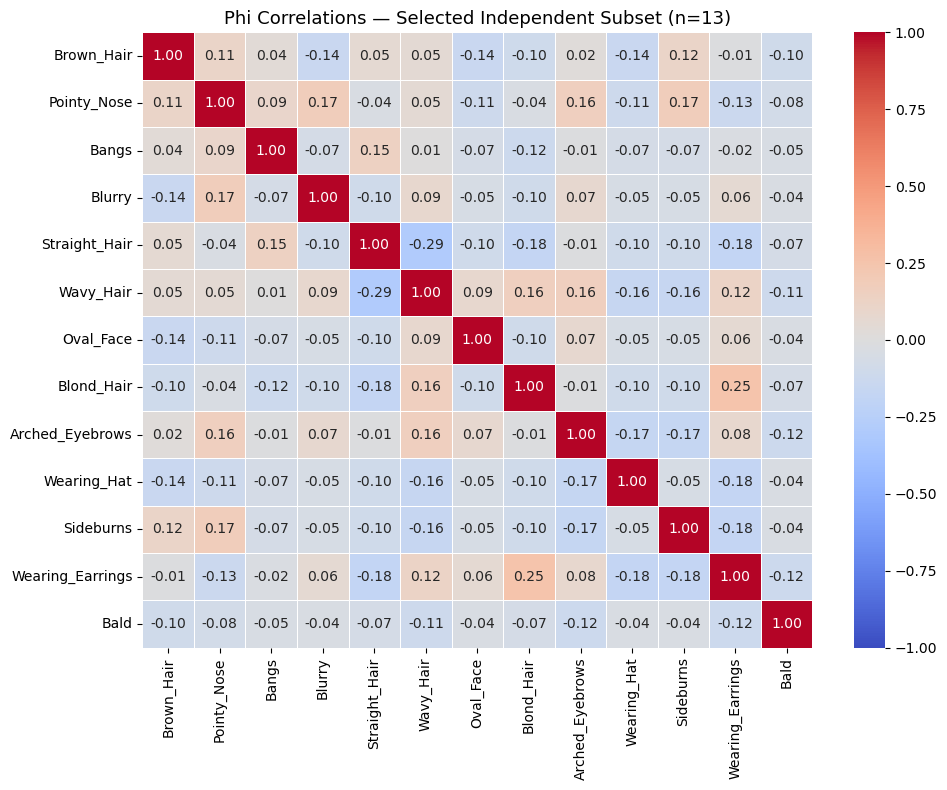


Max |φ| within selected subset: 0.29149154406506866


In [14]:
sub_corr = corr.loc[selected, selected]

plt.figure(figsize=(10, 8))
sns.heatmap(
    sub_corr,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    xticklabels=selected,
    yticklabels=selected,
    linewidths=0.5,
)
plt.title(f"Phi Correlations — Selected Independent Subset (n={len(selected)})", fontsize=13)
plt.tight_layout()
plt.savefig("celeba_subset_corr.png", dpi=150)
plt.show()

print("\nMax |φ| within selected subset:", sub_corr.where(
    np.triu(np.ones(sub_corr.shape), k=1).astype(bool)
).abs().max().max())